### Importing LIbs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("waste_india.csv")

In [3]:
df.head()

,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year
0,Mumbai,Plastic,6610,68,11191,9,Composting,3056,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
1,Mumbai,Organic,1181,56,11191,5,Composting,2778,12,Mumbai Landfill,"22.4265, 77.4931",45575,2019
2,Mumbai,E-Waste,8162,53,11191,8,Incineration,3390,13,Mumbai Landfill,"22.4265, 77.4931",45575,2019
3,Mumbai,Construction,8929,56,11191,5,Landfill,1498,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
4,Mumbai,Hazardous,5032,44,11191,7,Recycling,2221,16,Mumbai Landfill,"22.4265, 77.4931",45575,2019


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   City/District                      850 non-null    str  
 1   Waste Type                         850 non-null    str  
 2   Waste Generated (Tons/Day)         850 non-null    int64
 3   Recycling Rate (%)                 850 non-null    int64
 4   Population Density (People/km²)    850 non-null    int64
 5   Municipal Efficiency Score (1-10)  850 non-null    int64
 6   Disposal Method                    850 non-null    str  
 7   Cost of Waste Management (₹/Ton)   850 non-null    int64
 8   Awareness Campaigns Count          850 non-null    int64
 9   Landfill Name                      850 non-null    str  
 10  Landfill Location (Lat, Long)      850 non-null    str  
 11  Landfill Capacity (Tons)           850 non-null    int64
 12  Year                             

In [5]:
df.columns

Index(['City/District', 'Waste Type', 'Waste Generated (Tons/Day)',
       'Recycling Rate (%)', 'Population Density (People/km²)',
       'Municipal Efficiency Score (1-10)', 'Disposal Method',
       'Cost of Waste Management (₹/Ton)', 'Awareness Campaigns Count',
       'Landfill Name', 'Landfill Location (Lat, Long)',
       'Landfill Capacity (Tons)', 'Year'],
      dtype='str')

### Data Cleaning

In [6]:
df.columns = [
    'City',
    'Waste_Type',
    'Waste',
    'Recycling',
    'Population_Density',
    'Efficiency',
    'Disposal',
    'Cost',
    'Awareness',
    'Landfill_Name',
    'Landfill_Location',
    'Landfill_Capacity',
    'Year'
]

df.head()

,City,Waste_Type,Waste,Recycling,Population_Density,Efficiency,Disposal,Cost,Awareness,Landfill_Name,Landfill_Location,Landfill_Capacity,Year
0,Mumbai,Plastic,6610,68,11191,9,Composting,3056,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
1,Mumbai,Organic,1181,56,11191,5,Composting,2778,12,Mumbai Landfill,"22.4265, 77.4931",45575,2019
2,Mumbai,E-Waste,8162,53,11191,8,Incineration,3390,13,Mumbai Landfill,"22.4265, 77.4931",45575,2019
3,Mumbai,Construction,8929,56,11191,5,Landfill,1498,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
4,Mumbai,Hazardous,5032,44,11191,7,Recycling,2221,16,Mumbai Landfill,"22.4265, 77.4931",45575,2019


In [7]:
df_city_year = df.groupby(['City', 'Year']).agg({
    'Waste': 'sum',
    'Recycling': 'mean',
    'Population_Density': 'mean',
    'Efficiency': 'mean',
    'Cost': 'mean',
    'Awareness': 'mean',
    'Landfill_Capacity': 'mean'
}).reset_index()

df_city_year.head()

,City,Year,Waste,Recycling,Population_Density,Efficiency,Cost,Awareness,Landfill_Capacity
0,Agra,2019,34463,48.8,4629.0,7.2,2636.4,10.0,82082.0
1,Agra,2020,24211,65.8,4629.0,6.8,2614.4,9.2,82082.0
2,Agra,2021,37337,49.8,4629.0,6.8,3014.0,7.2,82082.0
3,Agra,2022,15703,66.0,4629.0,6.8,2867.4,11.0,82082.0
4,Agra,2023,23151,55.8,4629.0,7.8,2732.4,7.4,82082.0


### Model Building

In [8]:
X = df_city_year.drop(['City', 'Waste'], axis=1)
y = df_city_year['Waste']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(136, 7) (34, 7)


In [10]:
X = df_city_year.drop(['City', 'Waste'], axis=1)
y = df_city_year['Waste']

In [11]:
# Train - Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [13]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [14]:
# XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [15]:
#comparing models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = pd.DataFrame(columns=['Model', 'MAE', 'RMSE', 'R2 Score'])

def add_result(name, y_true, y_pred):
    global results
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.loc[len(results)] = [name, mae, rmse, r2]

add_result('Linear Regression', y_test, y_pred_lr)
add_result('Random Forest', y_test, y_pred_rf)
add_result('XGBoost', y_test, y_pred_xgb)

print(results)

               Model          MAE         RMSE  R2 Score
0  Linear Regression  5042.997507  6062.881614 -0.020321
1      Random Forest  5313.310294  6213.011286 -0.071477
2            XGBoost  5777.688965  6764.478990 -0.270128


In [16]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
df_city_year['City_encoded'] = le_city.fit_transform(df_city_year['City'])

df_city_year.head()

,City,Year,Waste,Recycling,Population_Density,Efficiency,Cost,Awareness,Landfill_Capacity,City_encoded
0,Agra,2019,34463,48.8,4629.0,7.2,2636.4,10.0,82082.0,0
1,Agra,2020,24211,65.8,4629.0,6.8,2614.4,9.2,82082.0,0
2,Agra,2021,37337,49.8,4629.0,6.8,3014.0,7.2,82082.0,0
3,Agra,2022,15703,66.0,4629.0,6.8,2867.4,11.0,82082.0,0
4,Agra,2023,23151,55.8,4629.0,7.8,2732.4,7.4,82082.0,0


In [17]:
X = df_city_year.drop(['City', 'Waste'], axis=1)
y = df_city_year['Waste']

In [18]:
# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [19]:
#comparing models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = pd.DataFrame(columns=['Model', 'MAE', 'RMSE', 'R2 Score'])

def add_result(name, y_true, y_pred):
    global results
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.loc[len(results)] = [name, mae, rmse, r2]

add_result('Linear Regression', y_test, y_pred_lr)
add_result('Random Forest', y_test, y_pred_rf)
add_result('XGBoost', y_test, y_pred_xgb)

print(results)

               Model          MAE         RMSE  R2 Score
0  Linear Regression  5067.433160  6109.130298 -0.035947
1      Random Forest  5187.511176  6120.743945 -0.039889
2            XGBoost  5540.662598  6907.030621 -0.324224


### LTSM

In [20]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Sort data
df_city_year = df_city_year.sort_values(by=['City', 'Year'])

# Scale waste
scaler = MinMaxScaler()
df_city_year['Waste_scaled'] = scaler.fit_transform(df_city_year[['Waste']])

df_city_year.head()

,City,Year,Waste,Recycling,Population_Density,Efficiency,Cost,Awareness,Landfill_Capacity,City_encoded,Waste_scaled
0,Agra,2019,34463,48.8,4629.0,7.2,2636.4,10.0,82082.0,0,0.773251
1,Agra,2020,24211,65.8,4629.0,6.8,2614.4,9.2,82082.0,0,0.478881
2,Agra,2021,37337,49.8,4629.0,6.8,3014.0,7.2,82082.0,0,0.855773
3,Agra,2022,15703,66.0,4629.0,6.8,2867.4,11.0,82082.0,0,0.234588
4,Agra,2023,23151,55.8,4629.0,7.8,2732.4,7.4,82082.0,0,0.448445


In [21]:
sequences = []
targets = []

window_size = 3

for city in df_city_year['City'].unique():
    city_data = df_city_year[df_city_year['City'] == city]

    waste_values = city_data['Waste_scaled'].values

    for i in range(len(waste_values) - window_size):
        sequences.append(waste_values[i:i+window_size])
        targets.append(waste_values[i+window_size])

X_lstm = np.array(sequences)
y_lstm = np.array(targets)

print(X_lstm.shape, y_lstm.shape)

(68, 3) (68,)


In [22]:
X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))
print(X_lstm.shape)

(68, 3, 1)


In [23]:
from sklearn.model_selection import train_test_split

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42
)

print(X_train_lstm.shape, X_test_lstm.shape)

(54, 3, 1) (14, 3, 1)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

/Users/pratham07/Desktop/data analysis projects/smart waste/waste_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=8,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.3481 - val_loss: 0.3467
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3159 - val_loss: 0.3187
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2875 - val_loss: 0.2939
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2609 - val_loss: 0.2714
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2378 - val_loss: 0.2492
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2146 - val_loss: 0.2273
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1909 - val_loss: 0.2052
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1661 - val_loss: 0.1828
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1414 - val_loss: 0.1593
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1145 - val_loss: 0.1356
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0895 - val_loss: 0.1129
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0654 - val_loss: 0.0942


In [26]:
y_pred_lstm = lstm_model.predict(X_test_lstm)
print(y_pred_lstm[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
[[0.5028938 ]
 [0.50514007]
 [0.5336814 ]
 [0.48226783]
 [0.5711334 ]]


In [27]:
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_lstm)

print("Actual:")
print(y_test_actual[:5])

print("Predicted:")
print(y_pred_actual[:5])

Actual:
[[29515.]
 [32129.]
 [31153.]
 [29132.]
 [38461.]]
Predicted:
[[25047.281]
 [25125.512]
 [26119.521]
 [24328.941]
 [27423.861]]


In [28]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_lstm = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_lstm = np.sqrt(np.mean((y_test_actual - y_pred_actual) ** 2))
r2_lstm = r2_score(y_test_actual, y_pred_actual)

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
print("LSTM R2 Score:", r2_lstm)

LSTM MAE: 7698.4326171875
LSTM RMSE: 9332.377176760197
LSTM R2 Score: -0.09324078242748657


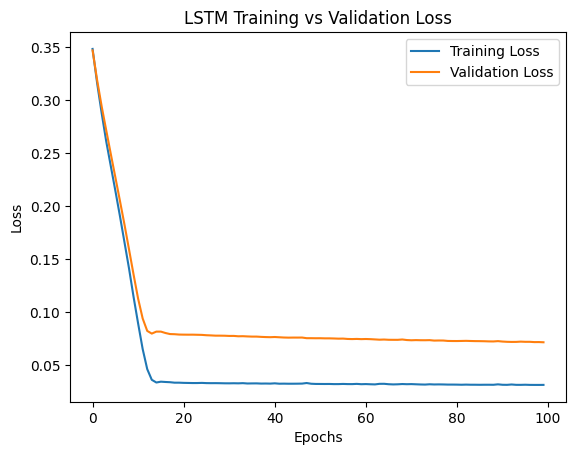

In [29]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.show()

In [30]:
# Take last sequence
last_sequence = X_lstm[-1]

# reshape
last_sequence = last_sequence.reshape((1, last_sequence.shape[0], 1))

# predict next value
next_pred_scaled = lstm_model.predict(last_sequence)

# convert back
next_pred = scaler.inverse_transform(next_pred_scaled)

print("Predicted Next Year Waste:", next_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted Next Year Waste: [[26036.184]]


### Advisory Engine

In [31]:
def generate_advisory(waste, recycling, efficiency, awareness, landfill):
    advice = []

    if waste > 130000:
        advice.append("High waste predicted: Increase collection frequency.")

    if recycling < 50:
        advice.append("Low recycling: Promote segregation campaigns.")

    if efficiency < 6:
        advice.append("Low efficiency: Improve municipal operations.")

    if awareness < 10:
        advice.append("Increase awareness campaigns.")

    if landfill < 40000:
        advice.append("Landfill capacity low: Plan alternative disposal.")

    if not advice:
        advice.append("Waste management is stable.")

    return advice